# Practice: Surface Waves

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS164/blob/main/notebooks/07_surface_wave_practice.ipynb)

### Learning Objectives:
- Compute the frequency of a fundamental mode Love Wave
- Compute the dispersion curve of Love Waves

**Prerequisites:** Algebra

**Reference:** Shearer, Chapter 8 (Surface Waves)

**Notebook Outline:**
- [Part (a): Fundamental Mode Love Wave Period](#part-a-fundamental-mode-love-wave-period)
- [Part (b): Build a Love-wave dispersion curve](#part-b-build-a-love-wave-dispersion-curve)
- [Part (c): Ambient Noise Tomography](#part-c-ambient-noise-tomography)

In [ ]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'obspy': 'obspy',
    'cartopy': 'cartopy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

In [ ]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg as la

---

## Part (a): Fundamental Mode Love Wave Period

An exact equation may be derived for Love wave dispersion within a homogeneous layer. Consider a surface layer overlying a higher velocity half-space (Figure 8.3). Equation (8.2) is still applicable, provided we replace the approximate $\pi/2$ phase shift at the turning point with the phase shift, $\phi_{S'S}$, resulting from the SH reflection off the bottom of the layer:

$$
\omega = \frac{n 2\pi - \phi_{S'S}}{\tau(p)}
$$

From (4.35), we may express the delay time $\tau$ as

$$
\tau(p) = 2h \sqrt{\frac{1}{\beta_1^2} - p^2}
\tag{8.8}
$$

where $h$ is the layer thickness and $\beta_1$ is the shear velocity in the top layer.

For postcritical reflections, it can be shown (see Exercise 8.1) from (6.46) and (6.59), and using $\mu = \rho \beta^2$, that

$$
\phi_{S'S} =
-2 \tan^{-1}
\left[
\frac{\mu_2}{\mu_1}
\frac{
\sqrt{p^2 - 1/\beta_2^2}
}{
\sqrt{1/\beta_1^2 - p^2}
}
\right]
\tag{8.9}
$$

Substituting (8.8) and (8.9) into (8.7), we obtain

$$
2 h \omega \sqrt{\frac{1}{\beta_1^2} - p^2}
- n 2\pi
=
2 \tan^{-1}
\left[
\frac{\mu_2}{\mu_1}
\frac{
\sqrt{p^2 - 1/\beta_2^2}
}{
\sqrt{1/\beta_1^2 - p^2}
}
\right]
\tag{8.10}
$$

or equivalently,

$$
\tan
\left(
h \omega \sqrt{\frac{1}{\beta_1^2} - p^2}
\right)
=
\frac{\mu_1}{\mu_2}
\frac{
\sqrt{1/\beta_1^2 - p^2}
}{
\sqrt{p^2 - 1/\beta_2^2}
}
\tag{8.11}
$$

This defines the dispersion curves for Love wave propagation within the layer.

Note that the phase velocity, $c = \frac{1}{p}$, varies between $\beta_1$ and $\beta_2$ (since $c > \beta_2$ is not postcritical). For every value of $c$, there are multiple values of $\omega$ because of the periodicity in the tangent function. The smallest of the $\omega$ values defines the **fundamental mode**, the second smallest is the **first higher mode**, and so on.

There is no analytical solution to (8.10) for $c$ as a function of $\omega$; the $c(\omega)$ values must therefore be determined numerically.


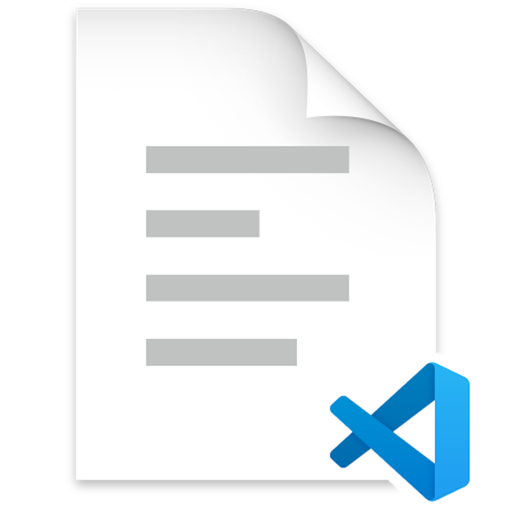

Use the values below:

- layer thickness: $h = 40\ \mathrm{km}$
- densities: $\rho_1 = 2.7\ \mathrm{g/cm^3}$, $\rho_2 = 3.3\ \mathrm{g/cm^3}$
- shear velocities: $\beta_1 = 3.5\ \mathrm{km/s}$, $\beta_2 = 4.5\ \mathrm{km/s}$
- phase velocity: $c = 3.8\ \mathrm{km/s}$

Your task is to compute the period of the **fundamental Love wave mode**.

1. Convert everything to consistent SI units.
2. Compute the slowness $p = 1/c$.
3. Use the dispersion relation to solve for $\omega$.
4. Convert angular frequency to period using $T = \frac{2\pi}{\omega}$.

Check your result against the example in the text.

In [3]:
import numpy as np

# --- Fill in the parameters here (use SI units) ---
h =         # layer thickness in m
rho1 =        # top-layer density in kg/m^3
rho2 =        # half-space density in kg/m^3
beta1 =       # top-layer shear velocity in m/s
beta2 =       # half-space shear velocity in m/s
c =           # phase velocity in m/s

# --- Compute slowness and shear moduli ---
p = # p=1/c
mu1 = # rho1 * beta1**2
mu2 = # rho2 * beta2**2

# --- Fundamental mode (n = 0) from Eq. (8.11) ---
# tan(h * omega * sqrt(1/beta1^2 - p^2)) = (mu2/mu1) * sqrt(p^2 - 1/beta2^2) / sqrt(1/beta1^2 - p^2)
arg =     # sqrt(1/beta1^2 - p^2))
rhs =     # right hand side

omega = np.arctan(rhs) / (h * arg)
T = 2.0 * np.pi / omega

print(f"p = {p:.6e} s/m")
print(f"mu2/mu1 = {mu2/mu1:.3f}")
print(f"omega = {omega:.6f} rad/s")
print(f"Period T = {T:.2f} s")

p = 2.631579e-04 s/m
mu2/mu1 = 2.020
omega = 0.269245 rad/s
Period T = 23.34 s


## Part (b): Build a Love Wave dispersion curve

In the previous exercise, you computed the period for a single phase velocity using the dispersion relation for Love waves in a single layer over a half-space.

Now extend that calculation to build **dispersion curves** for the fundamental mode and the first two higher modes.

Do the following:

1. Choose a range of phase velocities $c$ between $\beta_1$ and $\beta_2$.
2. For each value of $c$, compute the angular frequency $\omega$ for:
   - the fundamental mode ($n=0$),
   - the first higher mode ($n=1$),
   - the second higher mode ($n=2$).
3. Plot **phase velocity** $c$ on the vertical axis and **angular frequency** $\omega$ on the horizontal axis.
4. Compare the different modal branches and describe how the mode number changes the dispersion curve.

Use the same model parameters as before.

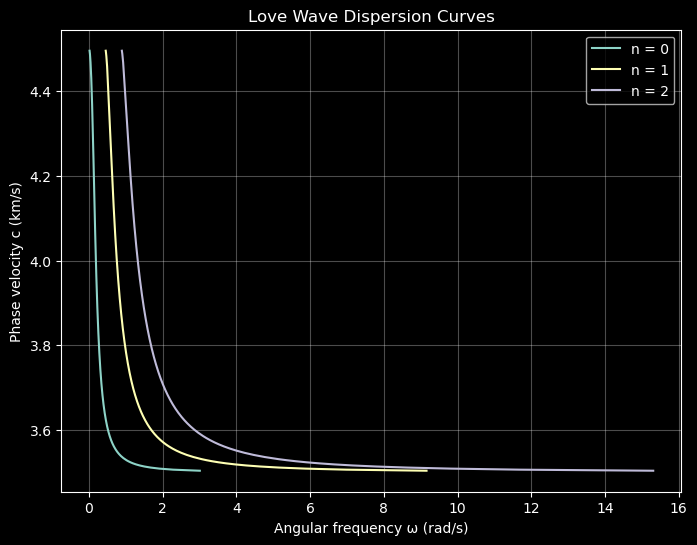

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Phase velocity range ---
# Must lie between beta1 and beta2
c_vals = np.linspace(beta1 * 1.001, beta2 * 0.999, 400)

# --- Compute omega(c) for modes n = 0, 1, 2 ---
modes = [0, 1, 2]
omegas = {}

for n in modes:
    omega_list = []
    for c in c_vals:

        p = 1.0 / c

        root1 = np.sqrt(1.0 / beta1**2 - p**2)
        root2 = np.sqrt(p**2 - 1.0 / beta2**2)

        rhs = (mu2 / mu1) * (root2 / root1)

        # Dispersion relation:
        # tan(h * omega * root1) = rhs
        omega = (np.arctan(rhs) + n * np.pi) / (h * root1)

        omega_list.append(omega)

    omegas[n] = np.array(omega_list)

# --- Plot dispersion curves ---
plt.figure(figsize=(8, 6))

for n in modes:
    plt.plot(omegas[n], c_vals / 1000.0, label=f"n = {n}")

plt.xlabel("Angular frequency ω (rad/s)")
plt.ylabel("Phase velocity c (km/s)")
plt.title("Love Wave Dispersion Curves")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Questions:**

1. Which mode has the lowest frequency for a given phase velocity?
2. Which modes exist at low frequency? Why do some modes disappear?
4. As frequency increases, what value does the phase velocity approach?
5. How would the curves change if the layer were thicker?
6. How would the curves change if the two shear velocities became more similar?
7. Which frequencies seem to sample the deeper half-space more strongly?

## Part (c): Ambient Noise Tomography

The following section introduces:
- ambient seismic noise sources,
- cross-correlation and empirical Green's functions,
- preprocessing steps,
- and extraction of surface-wave dispersion information from ambient noise.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.signal.cross_correlation import correlate
from obspy.geodetics import locations2degrees, degrees2kilometers

## 1. Find Stations in a Region

We use **Taiwan** for this demonstration — it has a dense broadband seismic network with stations spaced ~20–300 km apart, ideal for ambient noise analysis. Its location between the Philippine Sea and Eurasian plates also means strong ocean-generated noise from multiple directions.

We query the FDSN web service for stations with broadband (BH) channels, which record in the frequency range where ambient noise is strongest (~0.05–1 Hz).

In [ ]:
# Connect to FDSN data center
client = Client("IRIS")

# Query broadband stations in Taiwan
inventory = client.get_stations(
    minlatitude=22.1, maxlatitude=26.0,
    minlongitude=119.6, maxlongitude=121.8,
    starttime=UTCDateTime("2020-01-01"),
    endtime=UTCDateTime("2020-01-02"),
    channel="BH*",
    level="station",
)

# Store station names and coordinates
stations = {}
for network in inventory:
    for station in network:
        name = f"{network.code}.{station.code}"
        stations[name] = (station.latitude, station.longitude)

print(f"Found {len(stations)} stations:")
for name, (lat, lon) in stations.items():
    print(f"  {name}  ({lat:.2f}\u00b0N, {lon:.2f}\u00b0E)")

Found 13 stations:
  IU.TATO  (24.97°N, 121.50°E)
  TW.CHGB  (24.06°N, 121.17°E)
  TW.HGSD  (23.49°N, 121.42°E)
  TW.NACB  (24.17°N, 121.59°E)
  TW.RLNB  (23.89°N, 120.36°E)
  TW.SSLB  (23.79°N, 120.95°E)
  TW.TATO  (24.98°N, 121.49°E)
  TW.TDCB  (24.25°N, 121.16°E)
  TW.TPUB  (23.30°N, 120.63°E)
  TW.TWGB  (22.82°N, 121.08°E)
  TW.WFSB  (25.07°N, 121.78°E)
  TW.YHNB  (24.67°N, 121.38°E)
  TW.YULB  (23.39°N, 121.30°E)


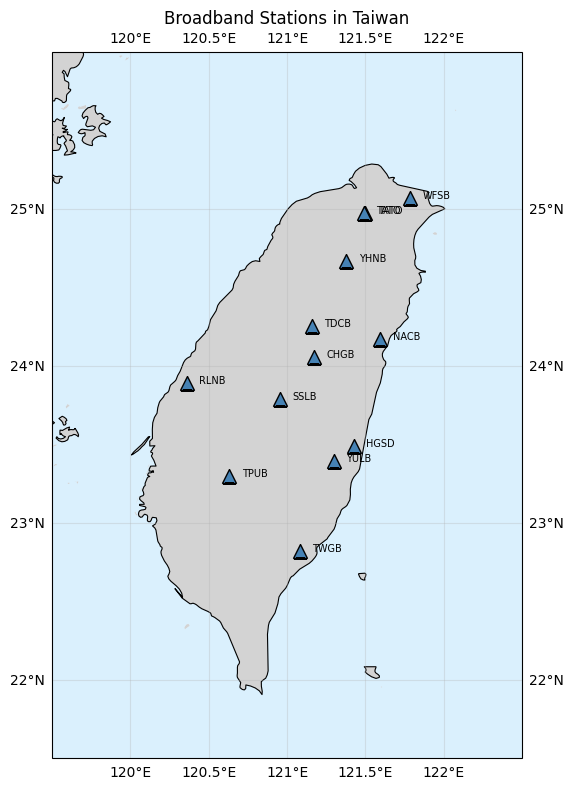

In [ ]:
fig = plt.figure(figsize=(6, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([119.5, 122.5, 21.5, 26.0], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.gridlines(draw_labels=True, alpha=0.3)

# Plot stations
for name, (lat, lon) in stations.items():
    ax.plot(lon, lat, '^', color='steelblue', markersize=10,
            markeredgecolor='k', transform=ccrs.PlateCarree())
    ax.text(lon + 0.08, lat, name.split('.')[1], fontsize=7,
            transform=ccrs.PlateCarree())

ax.set_title('Broadband Stations in Taiwan')
plt.tight_layout()
plt.show()

## 2. Station Pair Distances

The inter-station distance determines where the surface wave signal appears in the cross-correlation function:

$$\tau_{\text{arrival}} = \frac{D}{c}$$

- $D$: inter-station distance
- $c$: surface wave speed (~2–4 km/s)
- $\tau_{\text{arrival}}$: expected lag time in the CCF

Let's compute all pairwise distances and pick station pairs for the next steps.

In [ ]:
# Compute distances for the station pairs we will use later
pairs = [
    ("TW.NACB", "TW.YHNB"),
    ("TW.SSLB", "TW.TPUB"),
    ("TW.TPUB", "TW.YULB"),
    ("TW.NACB", "TW.SSLB"),
    ("TW.NACB", "TW.YULB"),
    ("TW.SSLB", "TW.YHNB"),
    ("TW.SSLB", "TW.TWGB"),
    ("TW.NACB", "TW.TPUB"),
]

for s1, s2 in pairs:
    lat1, lon1 = stations[s1]
    lat2, lon2 = stations[s2]
    dist = degrees2kilometers(locations2degrees(lat1, lon1, lat2, lon2))
    print(f"  {s1} — {s2}: {dist:6.1f} km")

  TW.NACB — TW.YHNB:   59.4 km
  TW.SSLB — TW.TPUB:   63.5 km
  TW.TPUB — TW.YULB:   68.9 km
  TW.NACB — TW.SSLB:   78.0 km
  TW.NACB — TW.YULB:   92.0 km
  TW.SSLB — TW.YHNB:  107.0 km
  TW.SSLB — TW.TWGB:  108.6 km
  TW.NACB — TW.TPUB:  138.1 km


## 3. Download Ambient Noise for a Station Pair

Let's pick two stations and download one day of vertical-component (BHZ) data. We'll use this to demonstrate cross-correlation step by step.

**Question:**

1. Try changing the channel component (BHE, BHN instead of BHZ) — how do the results differ?

In [ ]:
# Pick a station pair
sta1, sta2 = "TW.NACB", "TW.YHNB"

# Download one day of vertical-component data
starttime = UTCDateTime("2020-01-01")
endtime = UTCDateTime("2020-01-02")

net1, name1 = sta1.split(".")
net2, name2 = sta2.split(".")
st1 = client.get_waveforms(net1, name1, "", "BHZ", starttime, endtime)
st2 = client.get_waveforms(net2, name2, "", "BHZ", starttime, endtime)

print(f"Station 1: {st1[0]}")
print(f"Station 2: {st2[0]}")

At first glance, the recordings at both stations look like random noise. There's no obvious earthquake signal — just continuous background vibrations. Can we extract anything useful from this?

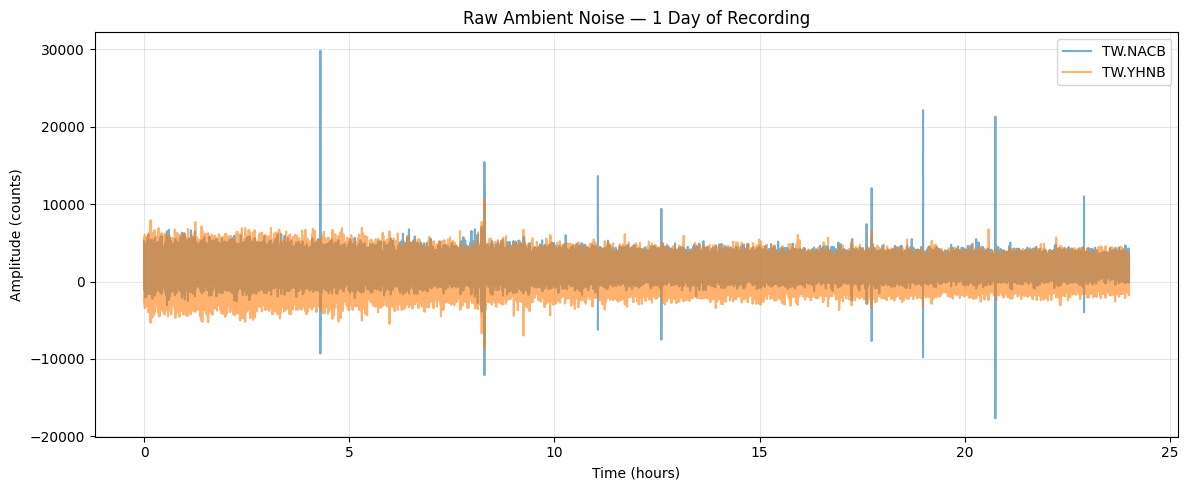

In [ ]:
# Plot 24 hours of raw ambient noise
sr = st1[0].stats.sampling_rate
time1 = np.arange(st1[0].stats.npts) / sr / 3600  # convert to hours
time2 = np.arange(st2[0].stats.npts) / sr / 3600

plt.figure(figsize=(12, 5))
plt.plot(time1, st1[0].data, label=sta1, alpha=0.6)
plt.plot(time2, st2[0].data, label=sta2, alpha=0.6)
plt.xlabel('Time (hours)')
plt.ylabel('Amplitude (counts)')
plt.title('Raw Ambient Noise \u2014 1 Day of Recording')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Cross-Correlation

**What is cross-correlation?** It measures the similarity between two signals as a function of a time shift (lag):

$$C_{AB}(\tau) = \int u_A(t) \, u_B(t + \tau) \, dt$$

**Why does this work for ambient noise?** Imagine ocean waves generating seismic noise from all directions. Some noise travels from station A to station B with a time delay $\tau = D/c$. When we cross-correlate long records, these coherent arrivals add up while random noise cancels out. The result looks like a **surface wave** traveling between the stations.

**Interpreting the CCF:**
- **Positive lag** ($\tau > 0$): waves traveling from station 1 $\to$ station 2
- **Negative lag** ($\tau < 0$): waves traveling from station 2 $\to$ station 1
- If noise sources are evenly distributed, the CCF is roughly **symmetric**
- If noise comes mainly from one direction, one side is stronger

Let's preprocess the data and compute the cross-correlation step by step.

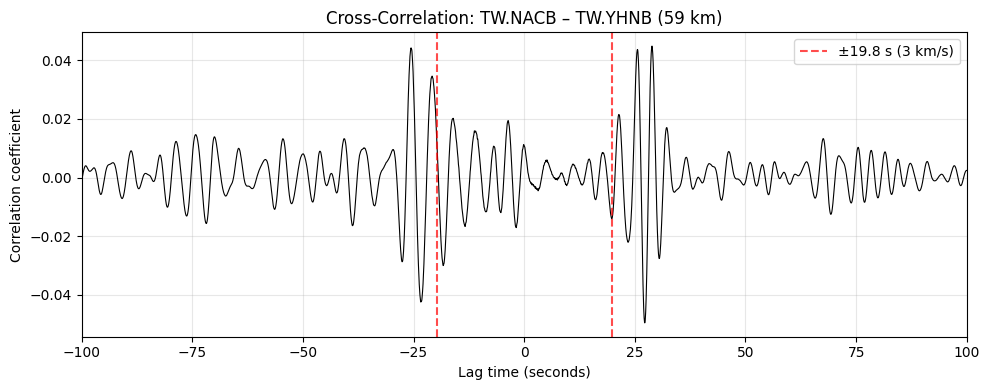

In [ ]:
# Copy traces so we can re-use the originals later
tr1 = st1[0].copy()
tr2 = st2[0].copy()

# Preprocessing
for tr in [tr1, tr2]:
    tr.detrend("demean")   # remove DC offset so signal centers on zero
    tr.detrend("linear")   # remove slow instrumental drift
    tr.taper(0.05)          # smooth edges to zero to prevent spectral artifacts

# Trim to common time window
t_start = max(tr1.stats.starttime, tr2.stats.starttime)
t_end = min(tr1.stats.endtime, tr2.stats.endtime)
tr1.trim(t_start, t_end)
tr2.trim(t_start, t_end)

# Cross-correlate (max lag = 300 seconds)
max_lag = 300
shift = int(tr1.stats.sampling_rate * max_lag)
ccf = correlate(tr1.data, tr2.data, shift=shift, normalize='naive')  # normalize by signal energy
lags = np.arange(-shift, shift + 1) / tr1.stats.sampling_rate

# Inter-station distance
lat1, lon1 = stations[sta1]
lat2, lon2 = stations[sta2]
dist_km = degrees2kilometers(locations2degrees(lat1, lon1, lat2, lon2))

# Plot
plt.figure(figsize=(10, 4))
plt.plot(lags, ccf, 'k', lw=0.8)

# Mark expected surface wave arrival (~3 km/s)
t_arrival = dist_km / 3.0
plt.axvline(t_arrival, color='r', ls='--', alpha=0.7,
            label=f'\u00b1{t_arrival:.1f} s (3 km/s)')
plt.axvline(-t_arrival, color='r', ls='--', alpha=0.7)

plt.title(f'Cross-Correlation: {sta1} \u2013 {sta2} ({dist_km:.0f} km)')
plt.xlabel('Lag time (seconds)')
plt.ylabel('Correlation coefficient')
plt.xlim(-100, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Cross-Correlations at Different Distances

Now let's compute CCFs for multiple station pairs at different distances. If the signal in the CCF is a real surface wave, its arrival time should scale linearly with distance: $\tau = D/c$.

We'll plot the CCFs stacked by distance, with reference moveout lines.

**Question:**

1. Some pairs may show stronger signal on one side — what does that tell you about the noise source direction?

In [ ]:
def download_and_correlate(sta1, sta2, starttime, endtime, max_lag=300):
    """Download noise for two stations, preprocess, and cross-correlate."""
    net1, name1 = sta1.split(".")
    net2, name2 = sta2.split(".")

    st1 = client.get_waveforms(net1, name1, "", "BHZ", starttime, endtime)
    st2 = client.get_waveforms(net2, name2, "", "BHZ", starttime, endtime)

    tr1 = st1[0].copy()
    tr2 = st2[0].copy()

    for tr in [tr1, tr2]:
        tr.detrend("demean")
        tr.detrend("linear")
        tr.taper(0.05)

    # Resample if sampling rates differ
    if tr1.stats.sampling_rate != tr2.stats.sampling_rate:
        tr2.resample(tr1.stats.sampling_rate)

    # Trim to common time window
    t1 = max(tr1.stats.starttime, tr2.stats.starttime)
    t2 = min(tr1.stats.endtime, tr2.stats.endtime)
    tr1.trim(t1, t2)
    tr2.trim(t1, t2)

    # Cross-correlate
    shift = int(tr1.stats.sampling_rate * max_lag)
    ccf = correlate(tr1.data, tr2.data, shift=shift, normalize='naive')
    lags = np.arange(-shift, shift + 1) / tr1.stats.sampling_rate

    # Distance
    lat1, lon1 = stations[sta1]
    lat2, lon2 = stations[sta2]
    dist = degrees2kilometers(locations2degrees(lat1, lon1, lat2, lon2))

    return lags, ccf, dist

In [ ]:
# Station pairs at various distances
pairs = [
    ("TW.NACB", "TW.YHNB"),
    ("TW.SSLB", "TW.TPUB"),
    ("TW.TPUB", "TW.YULB"),
    ("TW.NACB", "TW.SSLB"),
    ("TW.NACB", "TW.YULB"),
    ("TW.SSLB", "TW.YHNB"),
    ("TW.SSLB", "TW.TWGB"),
    ("TW.NACB", "TW.TPUB"),
]

starttime = UTCDateTime("2020-01-01")
endtime = UTCDateTime("2020-01-02")

plt.figure(figsize=(10, 7))
for s1, s2 in pairs:
    lags, ccf, dist = download_and_correlate(s1, s2, starttime, endtime)
    n1, n2 = s1.split(".")[1], s2.split(".")[1]
    plt.plot(lags, ccf * 3 * dist + dist, label=f"{n1}–{n2}")

# Reference moveout lines for surface wave speeds
t = np.linspace(-100, 100, 500)
plt.plot(t, np.abs(3.0 * t), 'k--', lw=1, label='3.0 km/s')
plt.plot(t, np.abs(2.0 * t), 'k-', lw=1, label='2.0 km/s')

plt.title('Cross-Correlation Functions vs. Distance')
plt.xlabel('Lag time (seconds)')
plt.ylabel('Distance (km)')
plt.text(-95, 5, r'$\leftarrow$ Sta 2 to Sta 1', fontsize=9, ha='left')
plt.text(95, 5, r'Sta 1 to Sta 2 $\rightarrow$', fontsize=9, ha='right')
plt.xlim(-100, 100)
plt.ylim(0, 160)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 6. How CCFs Change with Time

Let's split the day into overlapping 3-hour windows and compute a CCF for each one. Individual windows are noisy, but the surface wave signal is visible in most of them. Stacking many windows would improve the signal — this is why ambient noise studies typically use weeks to months of data. (One day is enough for a demo, but published studies often stack 6–12 months for high-quality measurements.)

**Questions:**

1. What do you think drives the differences between windows?
2. Try changing the window length — how does that affect the results?

In [ ]:
sta1, sta2 = "TW.NACB", "TW.YHNB"
starttime = UTCDateTime("2020-01-01")
window_length = 10800  # 3 hours (seconds)
n_windows = 10

plt.figure(figsize=(8, 10))
for i in range(n_windows):
    t1 = starttime + i * window_length // 4  # 75% overlap
    t2 = t1 + window_length

    lags, ccf, dist = download_and_correlate(sta1, sta2, t1, t2)
    plt.plot(lags, ccf * 10 + i, label=t1.strftime("%H:%M"))

plt.title(f'CCF Time Evolution: {sta1} \u2013 {sta2}')
plt.xlabel('Lag time (seconds)')
plt.ylabel('Time window')
plt.xlim(-100, 100)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## Questions

1. Examine the cross-correlations computed above.
   What features suggest that the cross-correlation is recovering a surface-wave Green’s function between the stations?
2. Why do the stacked cross-correlations generally appear cleaner than the daily cross-correlations?
4. Surface waves at long periods generally travel faster than short-period surface waves.
   What does this imply about seismic velocity structure with depth?
5. Based on the dispersion measurements, what kinds of Earth structure could be inferred using ambient noise tomography?

---
## Summary

**Key takeaways:**

1. **Ambient noise is not random** — it contains coherent surface waves generated by ocean waves, wind, and human activity.
2. **Cross-correlation recovers surface waves** — by cross-correlating noise between two stations, we extract the surface wave Green's function, as if one station were a seismic source.
3. **Arrival time scales with distance** — the signal arrives at lag time $\tau \approx D/c$, where $D$ is the inter-station distance and $c \approx 2$–$4$ km/s for surface waves.
4. **Longer stacking improves signal** — individual short-window CCFs are noisy, but stacking over days to months produces clear, stable signals.
5. **Asymmetry reveals noise source direction** — if noise comes mainly from one direction, the CCF is stronger on one side (causal vs. acausal).
**Connection to other topics:** The surface wave travel times from ambient noise CCFs can be used for **seismic tomography** — mapping the velocity structure of the crust and upper mantle without needing earthquakes.